In [25]:
import jax.numpy as jnp
from jax import Array
import chromatix.functional as cf
import matplotlib.pyplot as plt

from chromatix.utils import outer, matvec, l2_sq_norm
from chromatix.utils.fft import ifft, fft
from chromatix import VectorField
import jax


%config InlineBackend.figure_format = 'retina'

In [2]:
n = 1.0  # background refractive index
dz = 1.0  # propagation distance
potential = jnp.ones((10, 1, 512, 512, 1, 3, 3))


# %% Define incoming field

field = cf.point_source(
    (512, 512),
    1.0,
    0.532,
    1.0,
    1.0,
    1.0,
    amplitude=cf.linear(1 / 2 * jnp.pi),
    scalar=False,
    pupil=lambda f: cf.square_pupil(f, 300),
)


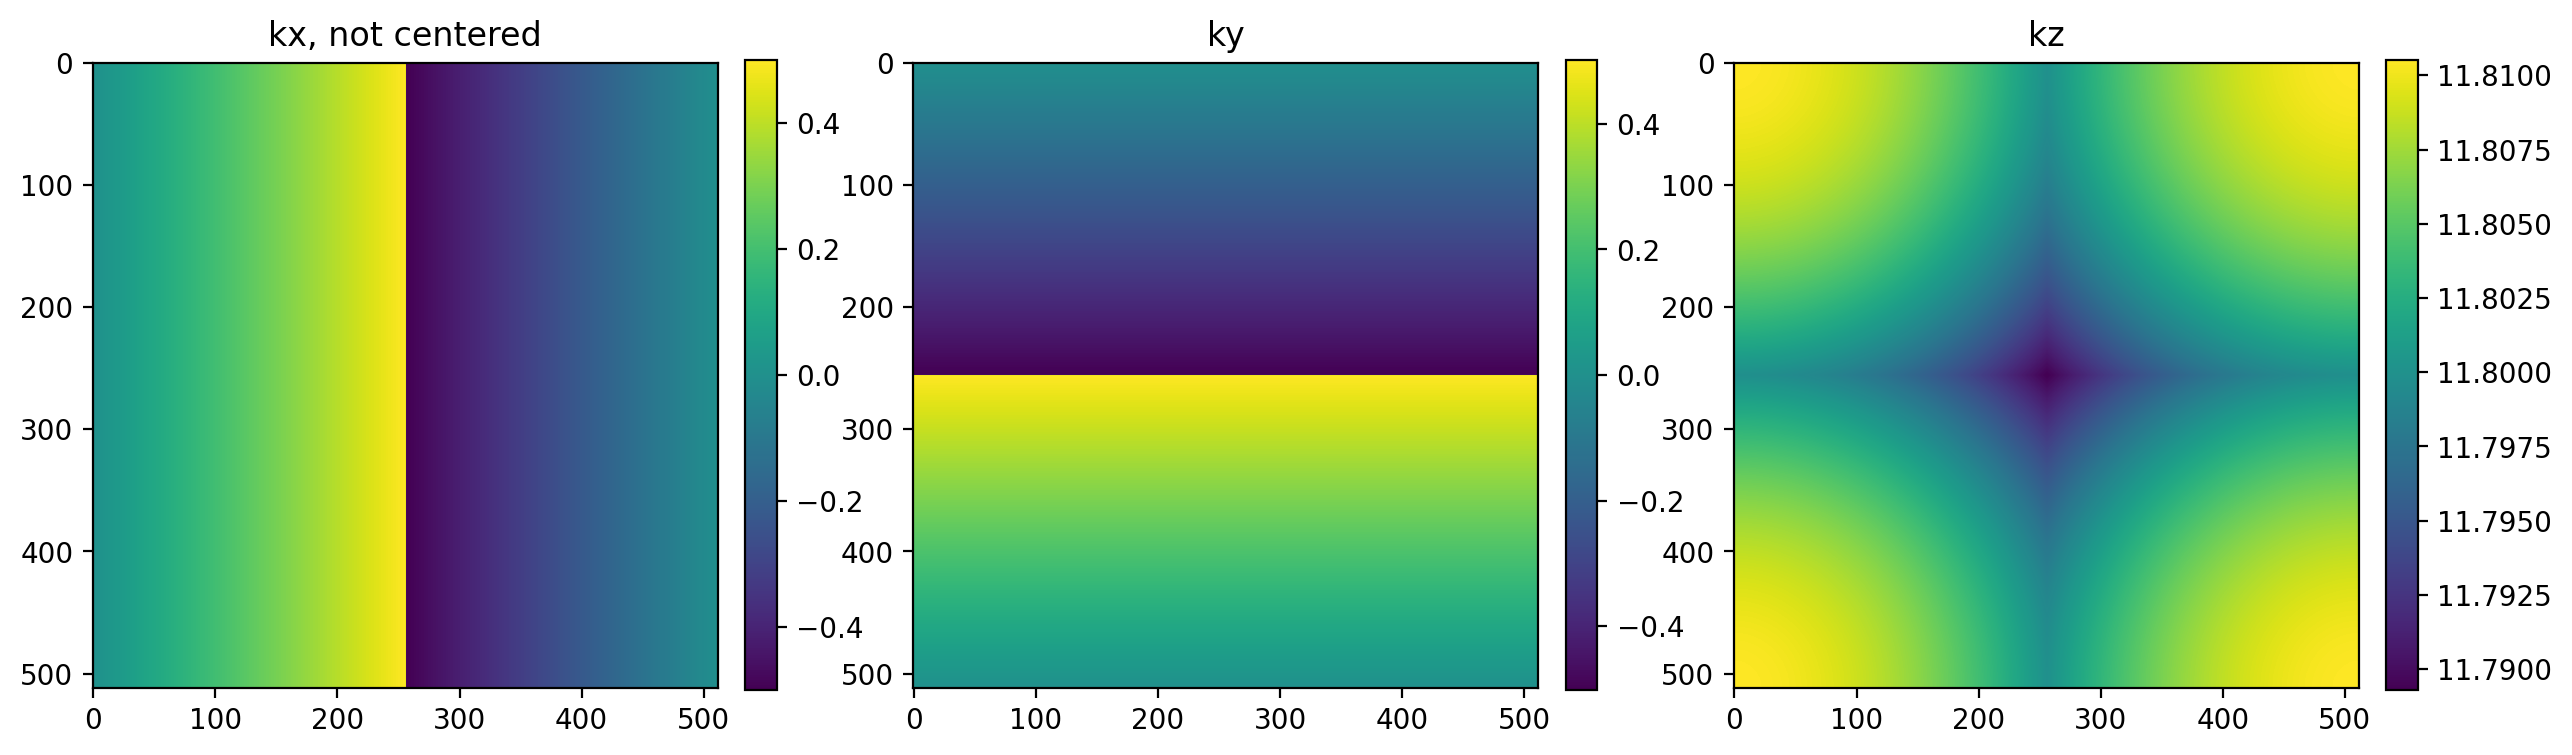

In [3]:
k = field.k_grid(n=n, centered=False)

plt.figure(figsize=(15, 5))
plt.subplot(131)

plt.title("kx, not centered")
plt.imshow(k[..., 0].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(132)
plt.title("ky")
plt.imshow(k[..., 1].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(133)
plt.title("kz")
plt.imshow(k[..., 2].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

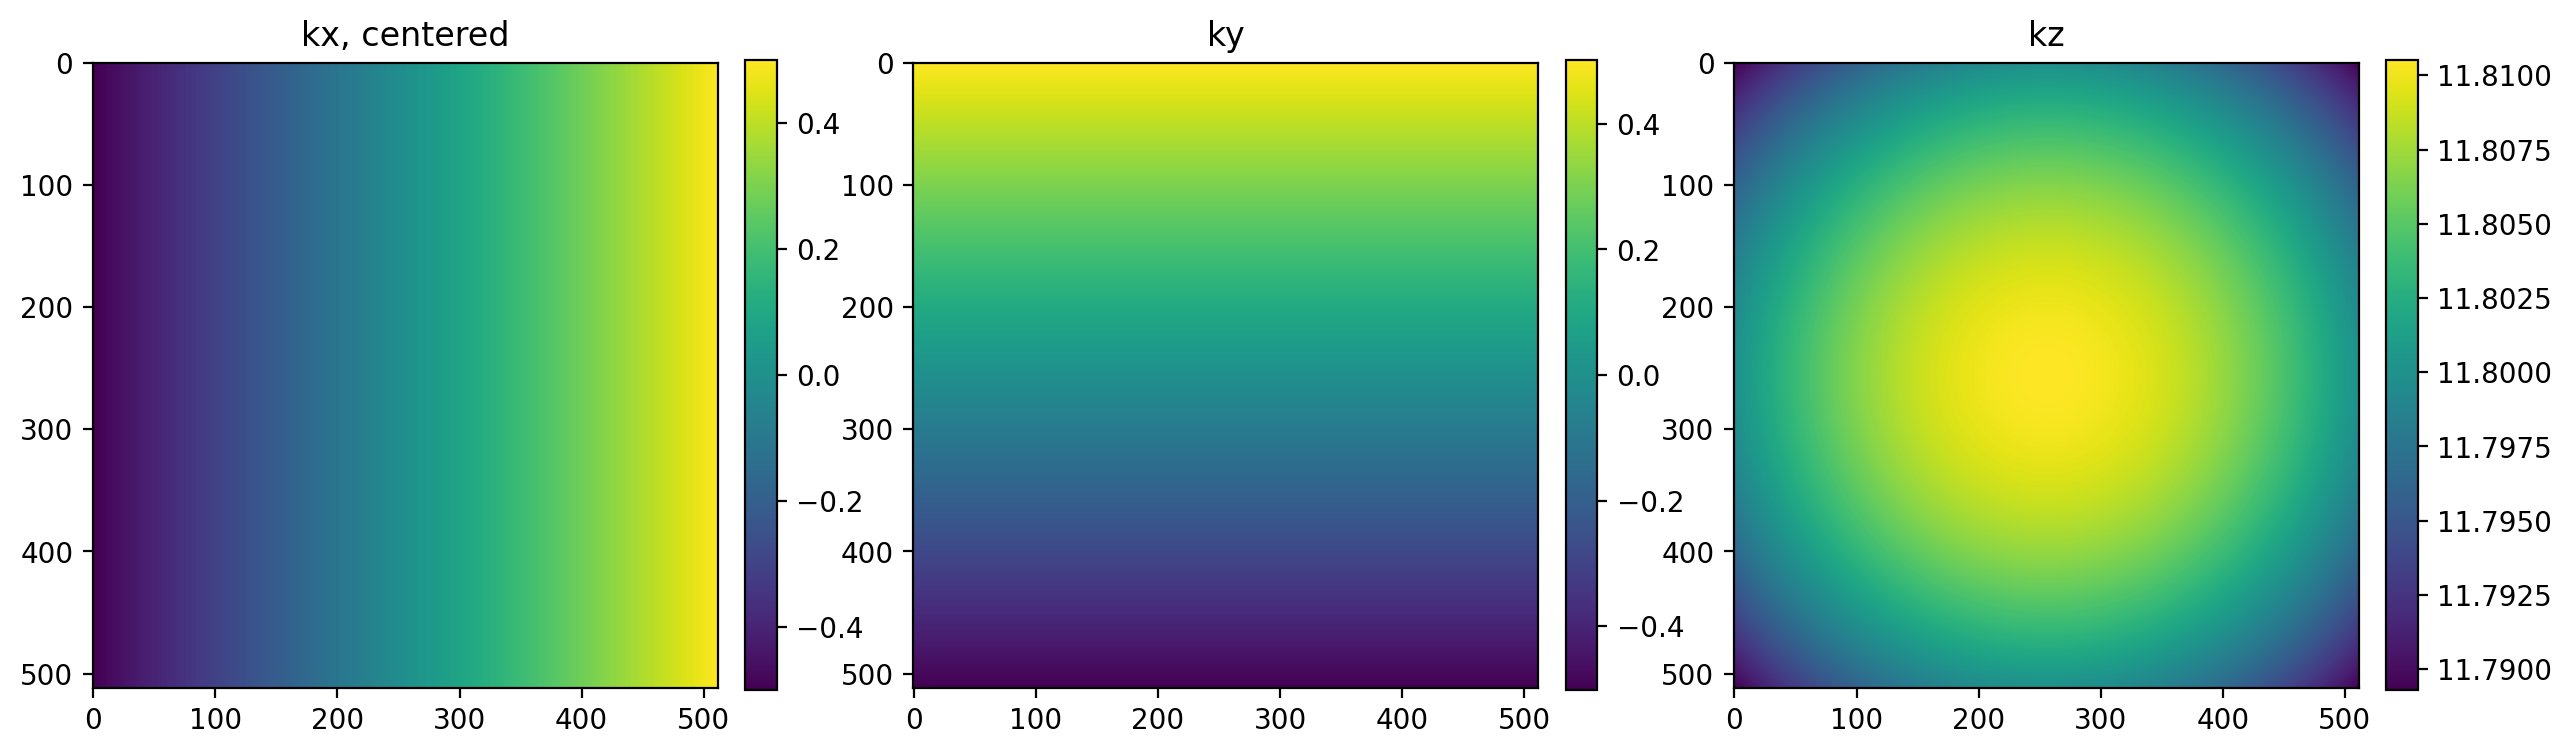

In [4]:
k = field.k_grid(n=n, centered=True)

plt.figure(figsize=(15, 5))
plt.subplot(131)

plt.title("kx, centered")
plt.imshow(k[..., 0].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(132)
plt.title("ky")
plt.imshow(k[..., 1].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(133)
plt.title("kz")
plt.imshow(k[..., 2].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

In [30]:
def thick_birefringent_sample(
    field: VectorField, scatter_potential: Array, dz: float, n: float
) -> VectorField:
    def P(u: Array) -> Array:
        phase_factor = jnp.exp(1j * kz * dz)
        return ifft(matvec(q, phase_factor * fft(u)))

    def Q(u: Array) -> Array:
        return ifft(matvec(q, fft(u)))

    def H(u: Array) -> Array:
        phase_factor = -1j * dz / 2 * jnp.exp(1j * kz * dz) / kz
        return ifft(matvec(q, phase_factor * fft(u)))

    def propagate_slice(u, potential_slice):
        scatter_field = matvec(potential_slice, Q(u))
        return P(u) + H(scatter_field), None

    k = field.k_grid(n=n, centered=False) # to align with fft
    q = jnp.eye(3) - outer(k, k) / field.wave_number(n=n) ** 2 # PTFT factor in paper
    kz = k[..., [-1]]

    # Scanning over field
    u, _ = jax.lax.scan(propagate_slice, field.u, scatter_potential)
    return field.replace(u=u)

In [7]:
# Prepping some vector fields.
k = field.k_grid(n=n, centered=False)
q = jnp.eye(3) - outer(k, k) / field.wave_number(n=n) ** 2
kz = k[..., [-1]]

In [8]:
q.shape

(1, 512, 512, 1, 3, 3)

In [14]:
field.spectrum.shape

(1, 1, 1, 1, 1)

In [9]:
q.squeeze()[256, 256]

Array([[ 0.9982147 ,  0.00179226,  0.04217673],
       [ 0.00179226,  0.9982007 , -0.04234181],
       [ 0.04217673, -0.04234181,  0.00358456]], dtype=float32)

In [11]:
field.dk.shape

(1, 1, 1, 1, 2)

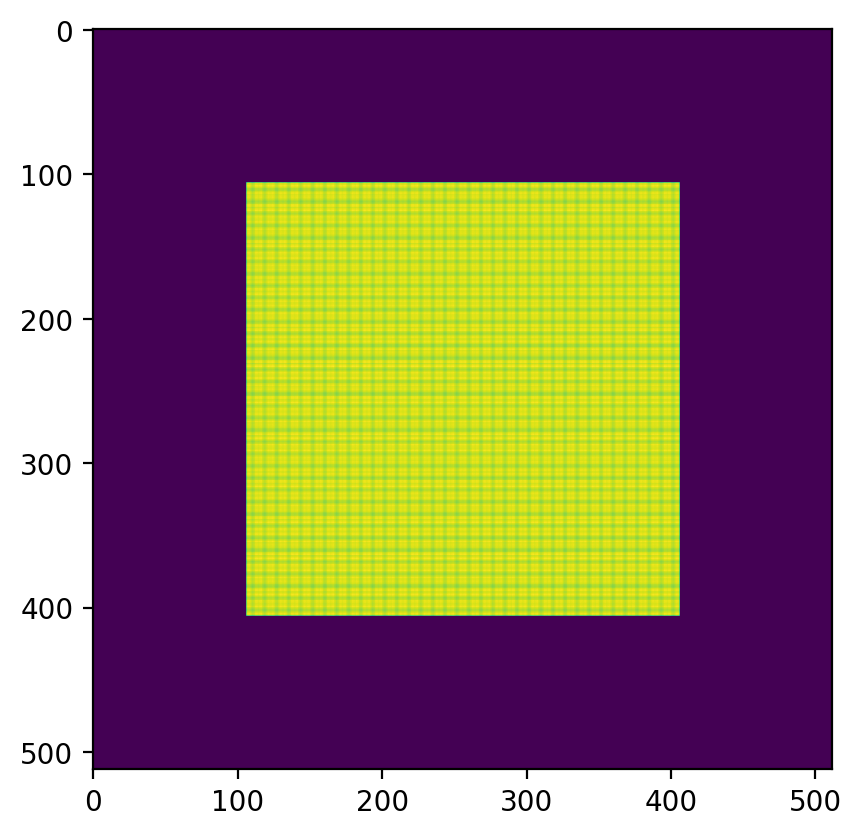

In [12]:
field_sample = thick_birefringent_sample(field, potential, dz, n)

# %%
plt.imshow(field_sample.intensity.squeeze())

In [6]:
field = cf.point_source(
    (512, 512),
    1.0,
    0.532,
    1.0,
    1.0,
    1.0,
    pupil=lambda f: cf.square_pupil(f, 300),
)


In [8]:
k.shape

(2, 1, 512, 512, 1, 1)

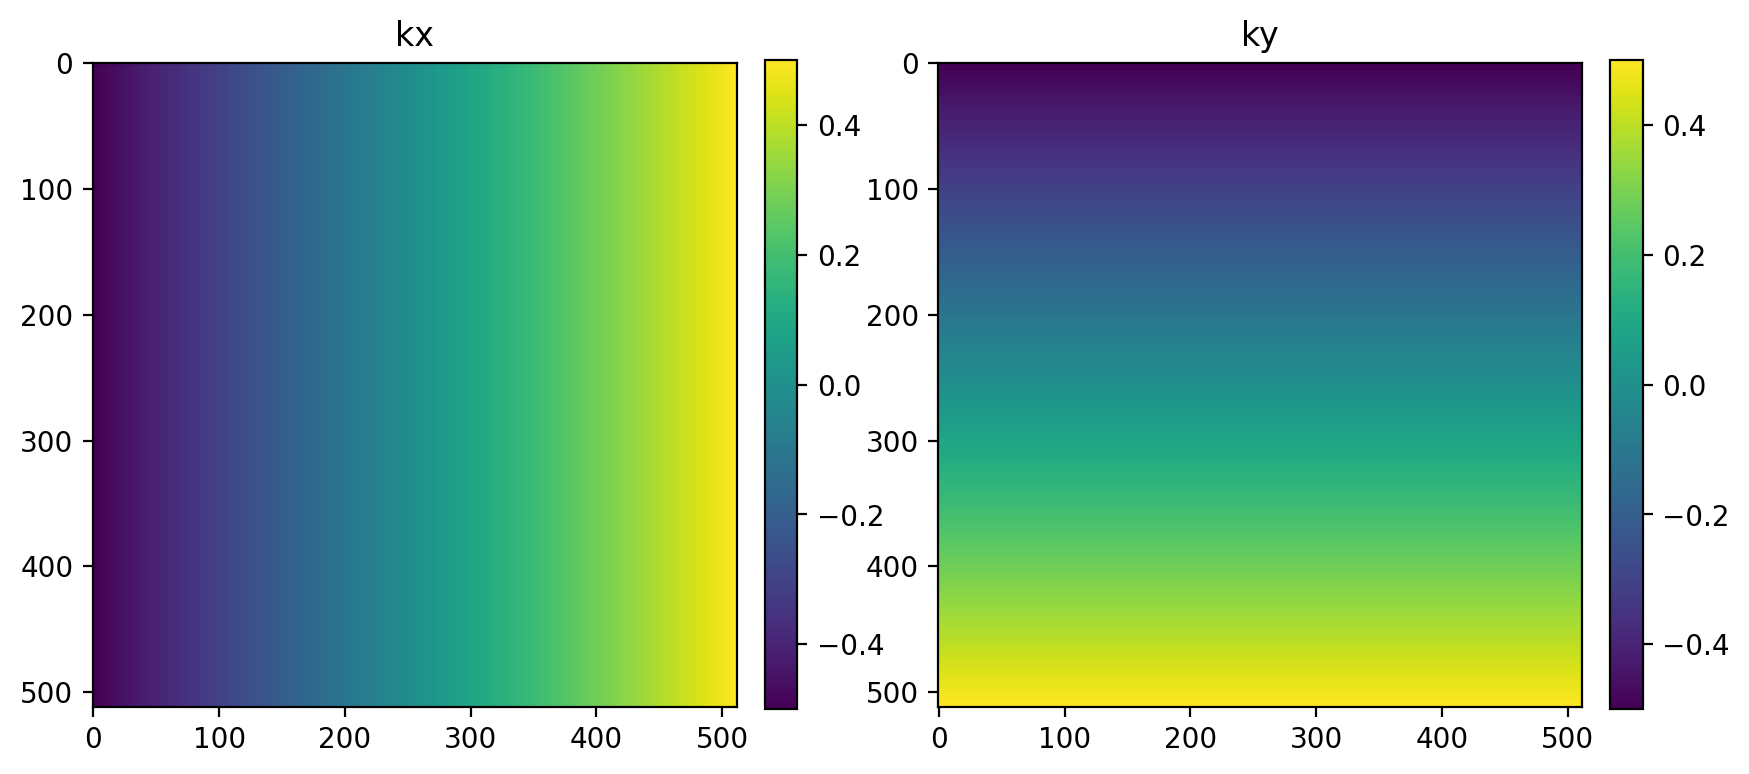

In [12]:
k = field.k_grid

plt.figure(figsize=(10, 5))
plt.subplot(121)

plt.title("kx")
plt.imshow(k[1].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(122)
plt.title("ky")
plt.imshow(k[0].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

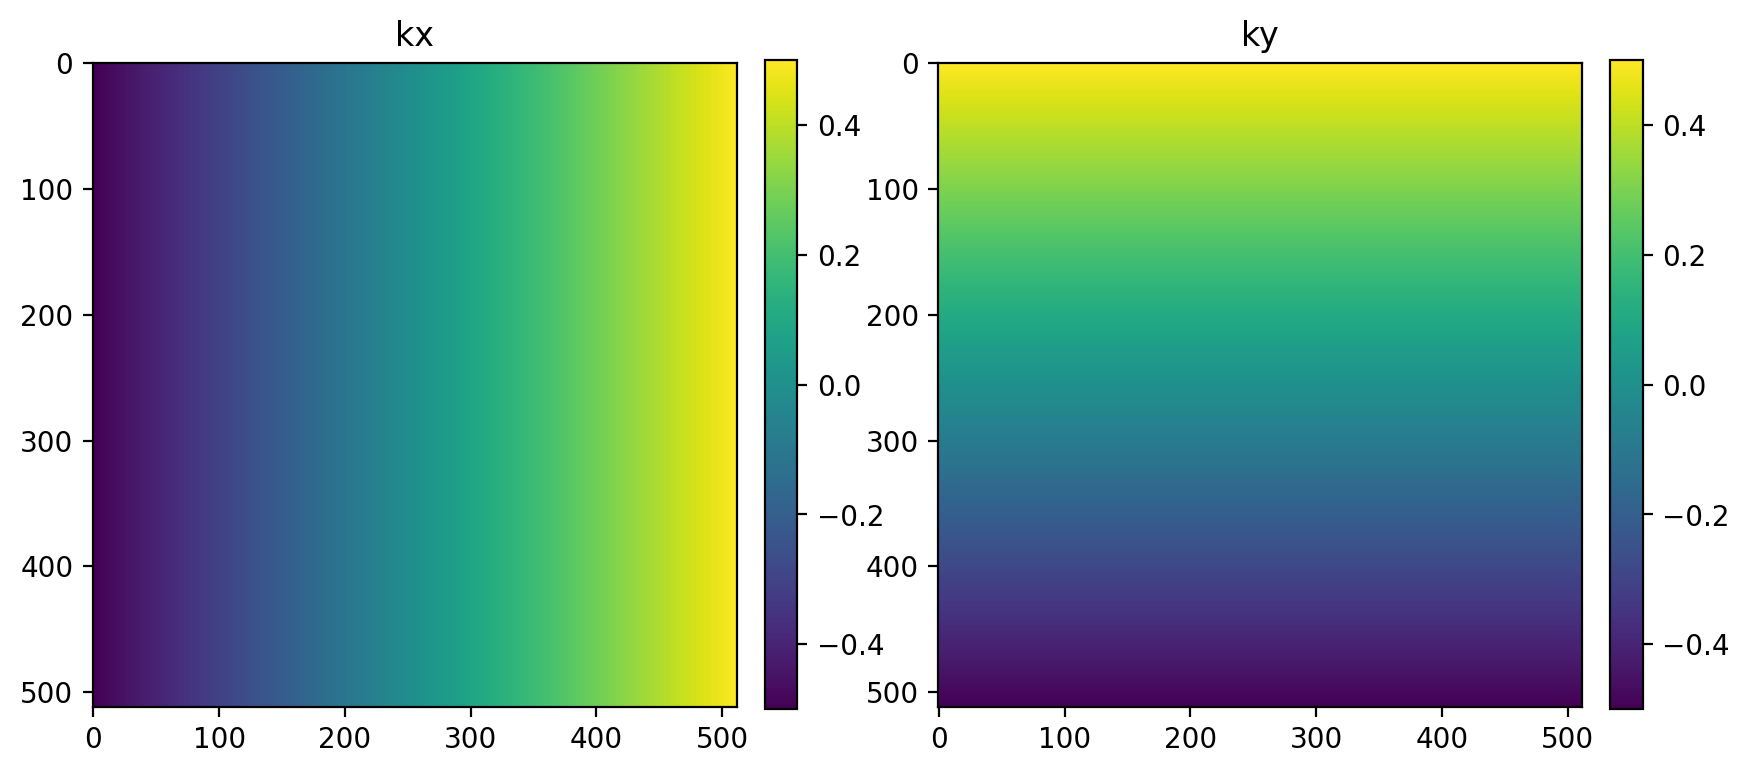

In [13]:
k = field.k_grid

plt.figure(figsize=(10, 5))
plt.subplot(121)

plt.title("kx")
plt.imshow(k[1].squeeze())
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(122)
plt.title("ky")
plt.imshow(k[0].squeeze()[::-1])
plt.colorbar(fraction=0.046, pad=0.04)

In [15]:
field = cf.point_source(
    (512, 512),
    1.0,
    0.532,
    1.0,
    1.0,
    1.0,
    pupil=lambda f: cf.square_pupil(f, 300),
)


In [28]:
def compute_transfer_propagator(
    field,
    z: Array,
    n: float,
    kxky = (0.0, 0.0),
) -> Array:
    """
    Compute propagation kernel for Fresnel propagation.
    Returns an array that can be multiplied with the Fourier transform of the
    incoming Field, as performed by kernel_propagate.

    Args:
        field: ``Field`` to be propagated.
        z: Distance(s) to propagate, either a float or a 1D array.
        n: A float that defines the refractive index of the medium.
        kykx: If provided, defines the orientation of the propagation. Should
            be an array of shape `[2,]` in the format [ky, kx].
    """
    def forward(z):
        l_sq = field.spectrum * z / n
        return -jnp.pi * l_sq * l2_sq_norm(field.k_grid(centered=False) - kxky)

    return jnp.exp(1j * phase)

In [29]:
compute_transfer_propagator(field, 1.0, 1.0)

TypeError: 'jaxlib.xla_extension.ArrayImpl' object is not callable